# ANÁLISIS DE DESBALANCE Y TÉCNICAS DE OVERSAMPLING

## Objetivo
Analizar el desbalance de clases en el dataset de patologías cerebrales y aplicar técnicas de sobremuestreo apropiadas para datos clínicos, comparando el rendimiento de modelos baseline antes y después del balanceo.

## Métricas clave
- **Recall por clase**: Sensibilidad clínica (no perder casos reales)
- **F1-score**: Balance precision-recall
- **Matriz de confusión**: Análisis detallado de errores

In [1]:
# Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Vectorización de texto
from sklearn.feature_extraction.text import TfidfVectorizer

# Técnicas de oversampling
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Métricas
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

# Configuración
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 1. Carga de datos y análisis de desbalance

In [3]:
# Cargar dataset procesado
df = pd.read_excel('../../data_cleaned.xlsx')

print("="*60)
print("INFORMACIÓN DEL DATASET")
print("="*60)
print(f"\nTotal de registros: {len(df)}")
print(f"Columnas: {df.shape[1]}")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())

# Variables de entrada y etiquetas
patologias = ['hemorragia', 'acv', 'fractura', 'masa']
print(f"\n{'='*60}")
print(f"PATOLOGÍAS A CLASIFICAR: {patologias}")
print(f"{'='*60}")

INFORMACIÓN DEL DATASET

Total de registros: 895
Columnas: 15

Columnas disponibles:
['Fecha(dd/mm/yyyy)', 'Modalidad', 'Estudio', 'Técnica', 'Datos Clínicos', 'Hallazgos', 'Opinión', 'Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal', 'hemorragia', 'acv', 'fractura', 'masa']

PATOLOGÍAS A CLASIFICAR: ['hemorragia', 'acv', 'fractura', 'masa']


In [4]:
# ANÁLISIS DE DESBALANCE POR CLASE
print("\n" + "="*60)
print("DISTRIBUCIÓN DE CLASES (ANÁLISIS DE DESBALANCE)")
print("="*60)

# Contar casos positivos por clase
class_counts = {}
for patologia in patologias:
    positivos = df[patologia].sum()
    negativos = len(df) - positivos
    ratio = positivos / len(df) * 100
    
    class_counts[patologia] = {
        'positivos': positivos,
        'negativos': negativos,
        'total': len(df),
        'ratio_positivos': ratio
    }
    
    print(f"\n{patologia.upper()}")
    print(f"  Positivos (1): {positivos:4d} ({ratio:5.2f}%)")
    print(f"  Negativos (0): {negativos:4d} ({100-ratio:5.2f}%)")
    print(f"  Ratio 1:0 = 1:{negativos/positivos:.2f}")

# Calcular imbalance ratio promedio
ratios = [v['negativos']/v['positivos'] for v in class_counts.values()]
avg_imbalance = np.mean(ratios)

print(f"\n{'='*60}")
print(f"RESUMEN DE DESBALANCE")
print(f"{'='*60}")
print(f"Ratio de desbalance promedio: 1:{avg_imbalance:.2f}")

if avg_imbalance > 3:
    print("⚠️  DESBALANCE MODERADO-ALTO detectado")
    print("   Recomendación: Aplicar técnicas de balanceo")
elif avg_imbalance > 1.5:
    print("⚠️  DESBALANCE LEVE detectado")
    print("   Recomendación: Considerar class_weight o oversampling")
else:
    print("✓  Clases relativamente balanceadas")


DISTRIBUCIÓN DE CLASES (ANÁLISIS DE DESBALANCE)

HEMORRAGIA
  Positivos (1):  719 (80.34%)
  Negativos (0):  176 (19.66%)
  Ratio 1:0 = 1:0.24

ACV
  Positivos (1):  397 (44.36%)
  Negativos (0):  498 (55.64%)
  Ratio 1:0 = 1:1.25

FRACTURA
  Positivos (1):  380 (42.46%)
  Negativos (0):  515 (57.54%)
  Ratio 1:0 = 1:1.36

MASA
  Positivos (1):  210 (23.46%)
  Negativos (0):  685 (76.54%)
  Ratio 1:0 = 1:3.26

RESUMEN DE DESBALANCE
Ratio de desbalance promedio: 1:1.53
⚠️  DESBALANCE LEVE detectado
   Recomendación: Considerar class_weight o oversampling


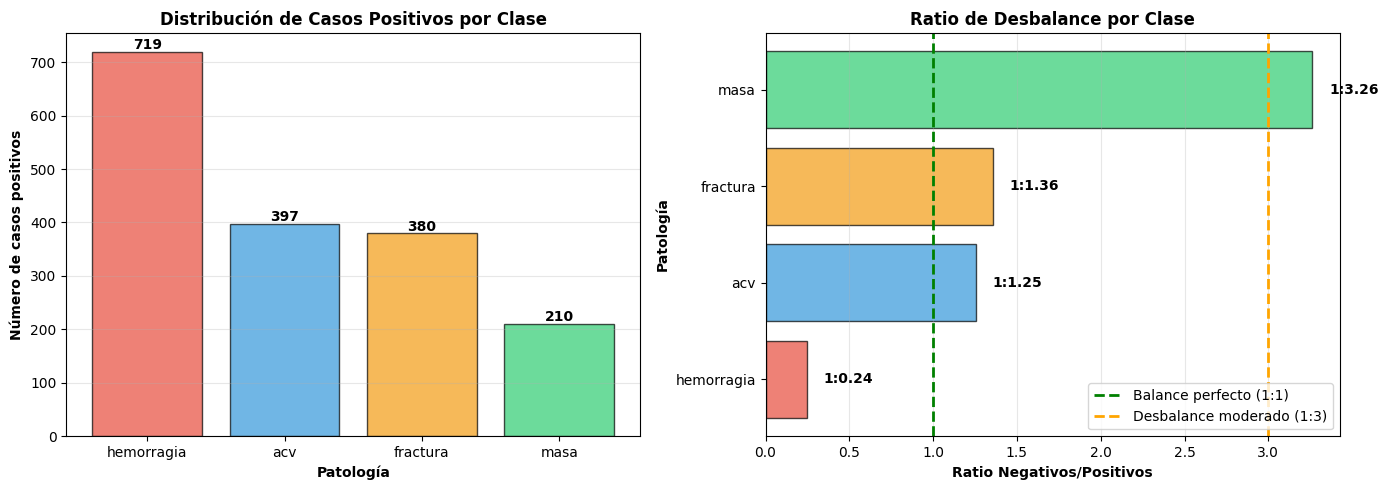

In [6]:
# VISUALIZACIÓN DEL DESBALANCE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de clases positivas
positivos = [class_counts[p]['positivos'] for p in patologias]
colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']

axes[0].bar(patologias, positivos, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Patología', fontweight='bold')
axes[0].set_ylabel('Número de casos positivos', fontweight='bold')
axes[0].set_title('Distribución de Casos Positivos por Clase', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, (pat, count) in enumerate(zip(patologias, positivos)):
    axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold')

# Gráfico 2: Ratio de desbalance
ratios_display = [class_counts[p]['negativos']/class_counts[p]['positivos'] for p in patologias]

axes[1].barh(patologias, ratios_display, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Ratio Negativos/Positivos', fontweight='bold')
axes[1].set_ylabel('Patología', fontweight='bold')
axes[1].set_title('Ratio de Desbalance por Clase', fontweight='bold', fontsize=12)
axes[1].axvline(x=1, color='green', linestyle='--', linewidth=2, label='Balance perfecto (1:1)')
axes[1].axvline(x=3, color='orange', linestyle='--', linewidth=2, label='Desbalance moderado (1:3)')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, (pat, ratio) in enumerate(zip(patologias, ratios_display)):
    axes[1].text(ratio + 0.1, i, f'1:{ratio:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()



## 2. Preparación de datos y vectorización

Transformamos el texto médico (campo `Hallazgos`) en features numéricas usando TF-IDF, manteniendo la misma configuración del notebook de Modelos Tradicionales para garantizar comparabilidad.

In [19]:
# Vectorización TF-IDF del texto médico
X_text = df['Hallazgos'].astype(str)

stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=stopwords_es
)

X = vectorizer.fit_transform(X_text)

print("="*60)
print("VECTORIZACIÓN TF-IDF")
print("="*60)
print(f"Shape de X: {X.shape}")
print(f"  - Muestras: {X.shape[0]}")
print(f"  - Features (términos TF-IDF): {X.shape[1]}")


VECTORIZACIÓN TF-IDF
Shape de X: (895, 200)
  - Muestras: 895
  - Features (términos TF-IDF): 200


## 3. Técnicas de Oversampling

### Justificación clínica de las técnicas seleccionadas:

**1. RandomOverSampler (ROS)**
- **Seguro para datos clínicos**: Duplica registros reales existentes sin modificar valores
- **No introduce artefactos**: Mantiene la integridad de los datos médicos originales
- **Validez clínica**: Cada muestra sobremuestreada corresponde a un caso real documentado
- **Limitación**: Puede causar overfitting al repetir exactamente los mismos casos

**2. SMOTE (Synthetic Minority Over-sampling TEchnique)**
- **Apropiado para TF-IDF**: Las features son frecuencias de términos (variables continuas)
- **Genera variabilidad**: Interpola entre casos similares en el espacio de características
- **Precaución clínica**: Los casos sintéticos NO son reportes reales, pero son combinaciones plausibles de términos médicos existentes
- **Limitación**: No debe usarse si las features representan valores diagnósticos absolutos (lab tests, mediciones exactas)

**Decisión**: Probaremos ambas técnicas y compararemos resultados.

In [8]:
# Función auxiliar para aplicar oversampling por clase
def aplicar_oversampling(X, y, metodo='random', random_state=42):
    """
    Aplica oversampling a clase minoritaria.
    
    Args:
        X: Features (matriz TF-IDF)
        y: Labels (array binario)
        metodo: 'random' o 'smote'
        random_state: Semilla para reproducibilidad
    
    Returns:
        X_resampled, y_resampled
    """
    if metodo == 'random':
        sampler = RandomOverSampler(random_state=random_state)
    elif metodo == 'smote':
        # SMOTE con k_neighbors=5 (por defecto)
        # Si hay menos de 6 muestras de clase minoritaria, usar k_neighbors menor
        n_minority = min(Counter(y).values())
        k_neighbors = min(5, n_minority - 1) if n_minority > 1 else 1
        sampler = SMOTE(k_neighbors=k_neighbors, random_state=random_state)
    else:
        raise ValueError("Método debe ser 'random' o 'smote'")
    
    X_resampled, y_resampled = sampler.fit_resample(X, y)
    
    return X_resampled, y_resampled

print("✓ Función de oversampling definida")

✓ Función de oversampling definida


## 4. Entrenamiento y evaluación: BASELINE (sin oversampling)

Primero establecemos el rendimiento baseline con datos desbalanceados originales.

In [9]:
# Función para evaluar modelo
def evaluar_modelo(modelo, X_train, X_test, y_train, y_test, nombre_modelo, nombre_patologia):
    """
    Entrena y evalúa un modelo, retornando métricas.
    """
    # Entrenar
    modelo.fit(X_train, y_train)
    
    # Predecir
    y_pred = modelo.predict(X_test)
    
    # Calcular métricas
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    
    return {
        'modelo': nombre_modelo,
        'patologia': nombre_patologia,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

print("✓ Función de evaluación definida")

✓ Función de evaluación definida


In [10]:
# BASELINE: Entrenar modelos SIN oversampling
print("="*70)
print("BASELINE: ENTRENAMIENTO SIN OVERSAMPLING (DATOS DESBALANCEADOS)")
print("="*70)

resultados_baseline = []

for patologia in patologias:
    print(f"\n{'─'*70}")
    print(f"Patología: {patologia.upper()}")
    print(f"{'─'*70}")
    
    y = df[patologia].values
    
    # Split estratificado
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Train set: {Counter(y_train)} | Test set: {Counter(y_test)}")
    
    # Modelo 1: Regresión Logística
    lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    metrics_lr = evaluar_modelo(lr_model, X_train, X_test, y_train, y_test, 
                                  'Logistic Regression', patologia)
    resultados_baseline.append(metrics_lr)
    
    print(f"  Logistic Regression → Recall: {metrics_lr['recall']:.3f} | "
          f"Precision: {metrics_lr['precision']:.3f} | F1: {metrics_lr['f1']:.3f}")
    
    # Modelo 2: Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    metrics_rf = evaluar_modelo(rf_model, X_train, X_test, y_train, y_test, 
                                 'Random Forest', patologia)
    resultados_baseline.append(metrics_rf)
    
    print(f"  Random Forest        → Recall: {metrics_rf['recall']:.3f} | "
          f"Precision: {metrics_rf['precision']:.3f} | F1: {metrics_rf['f1']:.3f}")

print(f"\n{'='*70}")
print("✓ Evaluación baseline completada")
print(f"{'='*70}")

BASELINE: ENTRENAMIENTO SIN OVERSAMPLING (DATOS DESBALANCEADOS)

──────────────────────────────────────────────────────────────────────
Patología: HEMORRAGIA
──────────────────────────────────────────────────────────────────────
Train set: Counter({1: 575, 0: 141}) | Test set: Counter({1: 144, 0: 35})
  Logistic Regression → Recall: 0.882 | Precision: 0.955 | F1: 0.917
  Random Forest        → Recall: 0.972 | Precision: 0.927 | F1: 0.949

──────────────────────────────────────────────────────────────────────
Patología: ACV
──────────────────────────────────────────────────────────────────────
Train set: Counter({0: 398, 1: 318}) | Test set: Counter({0: 100, 1: 79})
  Logistic Regression → Recall: 0.949 | Precision: 0.872 | F1: 0.909
  Random Forest        → Recall: 0.972 | Precision: 0.927 | F1: 0.949

──────────────────────────────────────────────────────────────────────
Patología: ACV
──────────────────────────────────────────────────────────────────────
Train set: Counter({0: 398, 1

## 5. Entrenamiento con RandomOverSampler (ROS)

In [11]:
# RANDOM OVERSAMPLER: Entrenar modelos CON oversampling
print("="*70)
print("RANDOM OVERSAMPLER: ENTRENAMIENTO CON DATOS BALANCEADOS")
print("="*70)

resultados_ros = []

for patologia in patologias:
    print(f"\n{'─'*70}")
    print(f"Patología: {patologia.upper()}")
    print(f"{'─'*70}")
    
    y = df[patologia].values
    
    # Split estratificado
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"ANTES del oversampling: {Counter(y_train)}")
    
    # Aplicar RandomOverSampler solo en train set
    X_train_balanced, y_train_balanced = aplicar_oversampling(
        X_train, y_train, metodo='random', random_state=42
    )
    
    print(f"DESPUÉS del oversampling: {Counter(y_train_balanced)}")
    print(f"Test set (sin modificar): {Counter(y_test)}")
    
    # Modelo 1: Regresión Logística
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    metrics_lr = evaluar_modelo(lr_model, X_train_balanced, X_test, 
                                  y_train_balanced, y_test, 
                                  'Logistic Regression (ROS)', patologia)
    resultados_ros.append(metrics_lr)
    
    print(f"  Logistic Regression → Recall: {metrics_lr['recall']:.3f} | "
          f"Precision: {metrics_lr['precision']:.3f} | F1: {metrics_lr['f1']:.3f}")
    
    # Modelo 2: Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    metrics_rf = evaluar_modelo(rf_model, X_train_balanced, X_test, 
                                 y_train_balanced, y_test, 
                                 'Random Forest (ROS)', patologia)
    resultados_ros.append(metrics_rf)
    
    print(f"  Random Forest        → Recall: {metrics_rf['recall']:.3f} | "
          f"Precision: {metrics_rf['precision']:.3f} | F1: {metrics_rf['f1']:.3f}")

print(f"\n{'='*70}")
print("✓ Evaluación con RandomOverSampler completada")
print(f"{'='*70}")

RANDOM OVERSAMPLER: ENTRENAMIENTO CON DATOS BALANCEADOS

──────────────────────────────────────────────────────────────────────
Patología: HEMORRAGIA
──────────────────────────────────────────────────────────────────────
ANTES del oversampling: Counter({1: 575, 0: 141})
DESPUÉS del oversampling: Counter({1: 575, 0: 575})
Test set (sin modificar): Counter({1: 144, 0: 35})
  Logistic Regression → Recall: 0.896 | Precision: 0.956 | F1: 0.925
  Random Forest        → Recall: 0.972 | Precision: 0.946 | F1: 0.959

──────────────────────────────────────────────────────────────────────
Patología: ACV
──────────────────────────────────────────────────────────────────────
ANTES del oversampling: Counter({0: 398, 1: 318})
DESPUÉS del oversampling: Counter({0: 398, 1: 398})
Test set (sin modificar): Counter({0: 100, 1: 79})
  Logistic Regression → Recall: 0.937 | Precision: 0.871 | F1: 0.902
  Random Forest        → Recall: 0.972 | Precision: 0.946 | F1: 0.959

────────────────────────────────────

## 6. Entrenamiento con SMOTE

In [12]:
# SMOTE: Entrenar modelos CON oversampling sintético
print("="*70)
print("SMOTE: ENTRENAMIENTO CON SOBREMUESTREO SINTÉTICO")
print("="*70)

resultados_smote = []

for patologia in patologias:
    print(f"\n{'─'*70}")
    print(f"Patología: {patologia.upper()}")
    print(f"{'─'*70}")
    
    y = df[patologia].values
    
    # Split estratificado
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"ANTES de SMOTE: {Counter(y_train)}")
    
    # Aplicar SMOTE solo en train set
    X_train_balanced, y_train_balanced = aplicar_oversampling(
        X_train, y_train, metodo='smote', random_state=42
    )
    
    print(f"DESPUÉS de SMOTE: {Counter(y_train_balanced)}")
    print(f"Test set (sin modificar): {Counter(y_test)}")
    
    # Modelo 1: Regresión Logística
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    metrics_lr = evaluar_modelo(lr_model, X_train_balanced, X_test, 
                                  y_train_balanced, y_test, 
                                  'Logistic Regression (SMOTE)', patologia)
    resultados_smote.append(metrics_lr)
    
    print(f"  Logistic Regression → Recall: {metrics_lr['recall']:.3f} | "
          f"Precision: {metrics_lr['precision']:.3f} | F1: {metrics_lr['f1']:.3f}")
    
    # Modelo 2: Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    metrics_rf = evaluar_modelo(rf_model, X_train_balanced, X_test, 
                                 y_train_balanced, y_test, 
                                 'Random Forest (SMOTE)', patologia)
    resultados_smote.append(metrics_rf)
    
    print(f"  Random Forest        → Recall: {metrics_rf['recall']:.3f} | "
          f"Precision: {metrics_rf['precision']:.3f} | F1: {metrics_rf['f1']:.3f}")

print(f"\n{'='*70}")
print("✓ Evaluación con SMOTE completada")
print(f"{'='*70}")

SMOTE: ENTRENAMIENTO CON SOBREMUESTREO SINTÉTICO

──────────────────────────────────────────────────────────────────────
Patología: HEMORRAGIA
──────────────────────────────────────────────────────────────────────
ANTES de SMOTE: Counter({1: 575, 0: 141})
DESPUÉS de SMOTE: Counter({1: 575, 0: 575})
Test set (sin modificar): Counter({1: 144, 0: 35})
  Logistic Regression → Recall: 0.889 | Precision: 0.955 | F1: 0.921
  Random Forest        → Recall: 0.931 | Precision: 0.944 | F1: 0.937

──────────────────────────────────────────────────────────────────────
Patología: ACV
──────────────────────────────────────────────────────────────────────
ANTES de SMOTE: Counter({0: 398, 1: 318})
DESPUÉS de SMOTE: Counter({0: 398, 1: 398})
Test set (sin modificar): Counter({0: 100, 1: 79})
  Logistic Regression → Recall: 0.937 | Precision: 0.871 | F1: 0.902
  Random Forest        → Recall: 0.931 | Precision: 0.944 | F1: 0.937

──────────────────────────────────────────────────────────────────────
Pato

## 7. Comparación de resultados

In [13]:
# Consolidar todos los resultados
todos_resultados = resultados_baseline + resultados_ros + resultados_smote

# Crear DataFrame para análisis
df_resultados = pd.DataFrame([{
    'Modelo': r['modelo'],
    'Patología': r['patologia'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1': r['f1']
} for r in todos_resultados])

# Tabla comparativa pivoteada
print("="*80)
print("TABLA COMPARATIVA: F1-SCORE POR MODELO Y PATOLOGÍA")
print("="*80)

pivot_f1 = df_resultados.pivot_table(
    index='Modelo', 
    columns='Patología', 
    values='F1'
)

print(pivot_f1.to_string())

print("\n" + "="*80)
print("TABLA COMPARATIVA: RECALL POR MODELO Y PATOLOGÍA")
print("="*80)

pivot_recall = df_resultados.pivot_table(
    index='Modelo', 
    columns='Patología', 
    values='Recall'
)

print(pivot_recall.to_string())

TABLA COMPARATIVA: F1-SCORE POR MODELO Y PATOLOGÍA
Patología                         acv  fractura  hemorragia      masa
Modelo                                                               
Logistic Regression          0.909091  0.909091    0.916968  0.824742
Logistic Regression (ROS)    0.902439  0.922078    0.924731  0.812500
Logistic Regression (SMOTE)  0.902439  0.909091    0.920863  0.842105
Random Forest                0.974359  0.953020    0.949153  0.732394
Random Forest (ROS)          0.974359  0.953642    0.958904  0.790123
Random Forest (SMOTE)        0.974359  0.946667    0.937063  0.843373

TABLA COMPARATIVA: RECALL POR MODELO Y PATOLOGÍA
Patología                         acv  fractura  hemorragia      masa
Modelo                                                               
Logistic Regression          0.949367  0.921053    0.881944  0.952381
Logistic Regression (ROS)    0.936709  0.934211    0.895833  0.928571
Logistic Regression (SMOTE)  0.936709  0.921053    0.888889

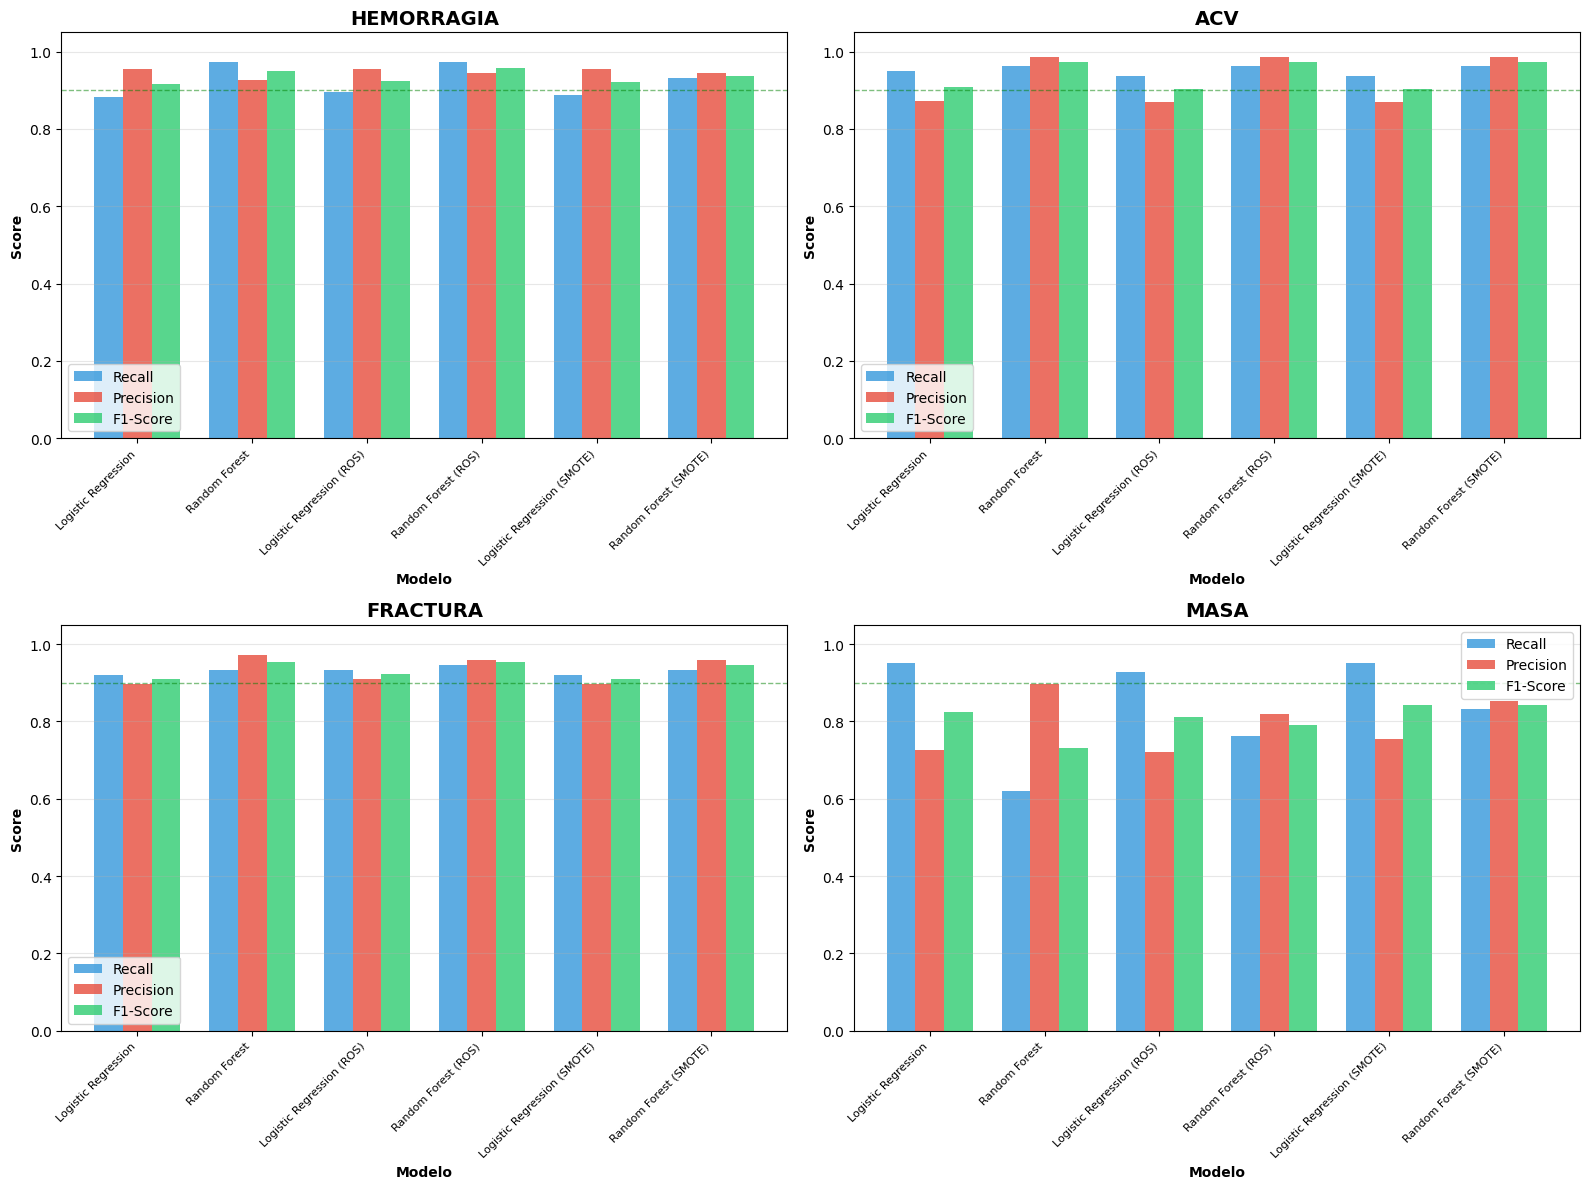

In [20]:
# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, patologia in enumerate(patologias):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Filtrar datos para esta patología
    df_pat = df_resultados[df_resultados['Patología'] == patologia]
    
    # Preparar datos para gráfico
    modelos = df_pat['Modelo'].tolist()
    recall_vals = df_pat['Recall'].tolist()
    precision_vals = df_pat['Precision'].tolist()
    f1_vals = df_pat['F1'].tolist()
    
    x = np.arange(len(modelos))
    width = 0.25
    
    # Barras agrupadas
    ax.bar(x - width, recall_vals, width, label='Recall', color='#3498db', alpha=0.8)
    ax.bar(x, precision_vals, width, label='Precision', color='#e74c3c', alpha=0.8)
    ax.bar(x + width, f1_vals, width, label='F1-Score', color='#2ecc71', alpha=0.8)
    
    # Configuración
    ax.set_xlabel('Modelo', fontweight='bold')
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title(f'{patologia.upper()}', fontweight='bold', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, rotation=45, ha='right', fontsize=8)
    ax.legend()
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0.9, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Target: 0.90')

plt.tight_layout()
plt.show()

In [15]:
# Análisis de mejora por técnica de oversampling
print("="*80)
print("ANÁLISIS DE MEJORA: BASELINE vs OVERSAMPLING")
print("="*80)

# Filtrar resultados por técnica
baseline_lr = df_resultados[df_resultados['Modelo'] == 'Logistic Regression']
ros_lr = df_resultados[df_resultados['Modelo'] == 'Logistic Regression (ROS)']
smote_lr = df_resultados[df_resultados['Modelo'] == 'Logistic Regression (SMOTE)']

print("\n--- LOGISTIC REGRESSION ---")
for patologia in patologias:
    f1_base = baseline_lr[baseline_lr['Patología'] == patologia]['F1'].values[0]
    recall_base = baseline_lr[baseline_lr['Patología'] == patologia]['Recall'].values[0]
    
    f1_ros = ros_lr[ros_lr['Patología'] == patologia]['F1'].values[0]
    recall_ros = ros_lr[ros_lr['Patología'] == patologia]['Recall'].values[0]
    
    f1_smote = smote_lr[smote_lr['Patología'] == patologia]['F1'].values[0]
    recall_smote = smote_lr[smote_lr['Patología'] == patologia]['Recall'].values[0]
    
    mejora_f1_ros = (f1_ros - f1_base) * 100
    mejora_recall_ros = (recall_ros - recall_base) * 100
    
    mejora_f1_smote = (f1_smote - f1_base) * 100
    mejora_recall_smote = (recall_smote - recall_base) * 100
    
    print(f"\n{patologia.upper()}")
    print(f"  Baseline:  F1={f1_base:.3f} | Recall={recall_base:.3f}")
    print(f"  ROS:       F1={f1_ros:.3f} ({mejora_f1_ros:+.1f}%) | Recall={recall_ros:.3f} ({mejora_recall_ros:+.1f}%)")
    print(f"  SMOTE:     F1={f1_smote:.3f} ({mejora_f1_smote:+.1f}%) | Recall={recall_smote:.3f} ({mejora_recall_smote:+.1f}%)")
    
    if mejora_recall_ros > 5 or mejora_recall_smote > 5:
        print(f"  ✓ MEJORA SIGNIFICATIVA en Recall")
    elif mejora_recall_ros < -5 or mejora_recall_smote < -5:
        print(f"  ⚠️ DEGRADACIÓN en Recall")

print("\n" + "="*80)

ANÁLISIS DE MEJORA: BASELINE vs OVERSAMPLING

--- LOGISTIC REGRESSION ---

HEMORRAGIA
  Baseline:  F1=0.917 | Recall=0.882
  ROS:       F1=0.925 (+0.8%) | Recall=0.896 (+1.4%)
  SMOTE:     F1=0.921 (+0.4%) | Recall=0.889 (+0.7%)

ACV
  Baseline:  F1=0.909 | Recall=0.949
  ROS:       F1=0.902 (-0.7%) | Recall=0.937 (-1.3%)
  SMOTE:     F1=0.902 (-0.7%) | Recall=0.937 (-1.3%)

FRACTURA
  Baseline:  F1=0.909 | Recall=0.921
  ROS:       F1=0.922 (+1.3%) | Recall=0.934 (+1.3%)
  SMOTE:     F1=0.909 (+0.0%) | Recall=0.921 (+0.0%)

MASA
  Baseline:  F1=0.825 | Recall=0.952
  ROS:       F1=0.812 (-1.2%) | Recall=0.929 (-2.4%)
  SMOTE:     F1=0.842 (+1.7%) | Recall=0.952 (+0.0%)



## 8. Matrices de confusión comparativas

Analizamos matrices de confusión para identificar tipos específicos de errores (FP vs FN).

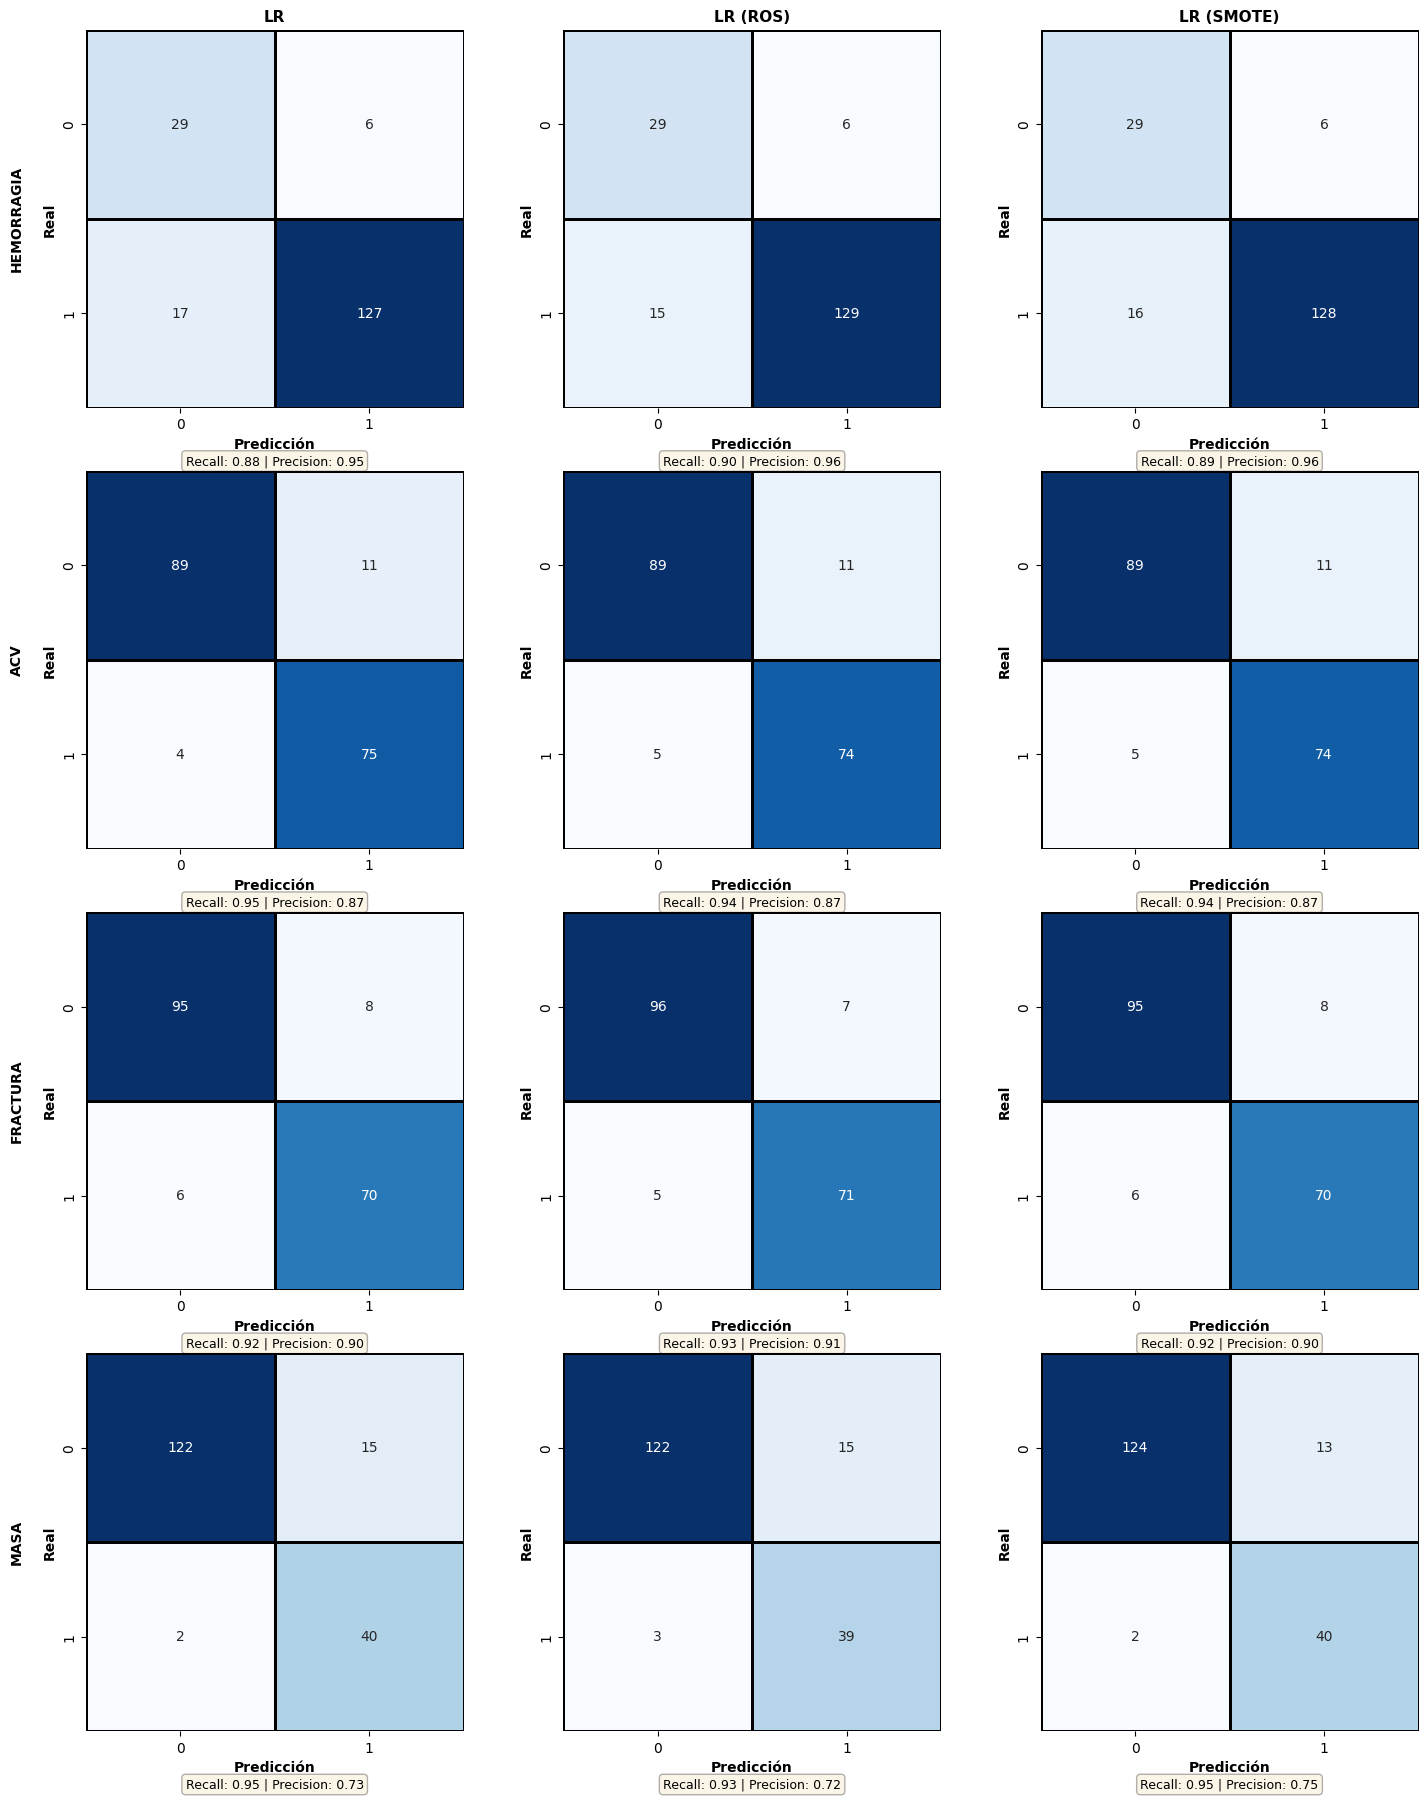

In [21]:
# Visualizar matrices de confusión para Logistic Regression
fig, axes = plt.subplots(4, 3, figsize=(15, 18))

tecnicas = ['Logistic Regression', 'Logistic Regression (ROS)', 'Logistic Regression (SMOTE)']

for idx_pat, patologia in enumerate(patologias):
    for idx_tec, tecnica in enumerate(tecnicas):
        ax = axes[idx_pat, idx_tec]
        
        # Obtener matriz de confusión
        resultado = [r for r in todos_resultados 
                     if r['modelo'] == tecnica and r['patologia'] == patologia]
        
        if resultado:
            cm = resultado[0]['confusion_matrix']
            
            # Visualizar
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                       cbar=False, square=True, linewidths=1, linecolor='black')
            
            ax.set_xlabel('Predicción', fontweight='bold')
            ax.set_ylabel('Real', fontweight='bold')
            
            if idx_pat == 0:
                titulo_tecnica = tecnica.replace('Logistic Regression', 'LR')
                ax.set_title(f'{titulo_tecnica}', fontweight='bold', fontsize=11)
            
            if idx_tec == 0:
                ax.set_ylabel(f'{patologia.upper()}\n\nReal', fontweight='bold')
            
            # Calcular FP y FN
            tn, fp, fn, tp = cm.ravel()
            recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
            precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
            
            # Agregar métricas como texto
            ax.text(0.5, -0.15, f'Recall: {recall_val:.2f} | Precision: {precision_val:.2f}',
                   ha='center', transform=ax.transAxes, fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()


## 9. Análisis de Riesgo de Overfitting

Comparamos el rendimiento en train vs test para detectar posibles señales de overfitting.

In [17]:
# Análisis de overfitting: comparar train score vs test score
print("="*80)
print("ANÁLISIS DE OVERFITTING")
print("="*80)
print("\nComparando F1-score en train (balanceado) vs test (original) para SMOTE")
print("Un gap grande (>10%) indica posible overfitting")
print("─"*80)

for patologia in patologias:
    y = df[patologia].values
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # SMOTE en train
    X_train_smote, y_train_smote = aplicar_oversampling(
        X_train, y_train, metodo='smote', random_state=42
    )
    
    # Entrenar modelo
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_smote, y_train_smote)
    
    # Predecir en train y test
    y_train_pred = model.predict(X_train_smote)
    y_test_pred = model.predict(X_test)
    
    # Calcular F1
    f1_train = f1_score(y_train_smote, y_train_pred, zero_division=0)
    f1_test = f1_score(y_test, y_test_pred, zero_division=0)
    
    gap = (f1_train - f1_test) * 100
    
    print(f"\n{patologia.upper()}")
    print(f"  F1 Train (SMOTE): {f1_train:.3f}")
    print(f"  F1 Test:          {f1_test:.3f}")
    print(f"  Gap:              {gap:+.1f}%", end="")
    
    if gap > 10:
        print(" ⚠️ ALTO RIESGO de overfitting")
    elif gap > 5:
        print(" ⚠️ Riesgo moderado de overfitting")
    else:
        print(" ✓ Overfitting controlado")

print("\n" + "="*80)
print("INTERPRETACIÓN:")
print("- Gap < 5%:  Modelo generaliza bien")
print("- Gap 5-10%: Leve overfitting, aceptable")
print("- Gap > 10%: Overfitting significativo, considerar regularización")
print("="*80)

ANÁLISIS DE OVERFITTING

Comparando F1-score en train (balanceado) vs test (original) para SMOTE
Un gap grande (>10%) indica posible overfitting
────────────────────────────────────────────────────────────────────────────────

HEMORRAGIA
  F1 Train (SMOTE): 0.914
  F1 Test:          0.921
  Gap:              -0.6% ✓ Overfitting controlado

ACV
  F1 Train (SMOTE): 0.936
  F1 Test:          0.902
  Gap:              +3.4% ✓ Overfitting controlado

FRACTURA
  F1 Train (SMOTE): 0.946
  F1 Test:          0.909
  Gap:              +3.7% ✓ Overfitting controlado

MASA
  F1 Train (SMOTE): 0.926
  F1 Test:          0.842
  Gap:              +8.4% ⚠️ Riesgo moderado de overfitting

INTERPRETACIÓN:
- Gap < 5%:  Modelo generaliza bien
- Gap 5-10%: Leve overfitting, aceptable
- Gap > 10%: Overfitting significativo, considerar regularización
